<a href="https://colab.research.google.com/github/Mithunraja96/Mithun/blob/master/SIG742Task2mithun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student ID: S224571163
# Student Name: Mithun Raja
# Student ID: S223563645
# Student Name: Dhilak Raj
# Student ID:
# Student Name:
# Attempted High Distinction Question: Yes

## Part I
### Data Acquisition and Manipulation

#### Here we need to use spark to read the unzipped (csv) data for starting. And for that I have installed pyspark and SparkSession.

In [8]:
!pip install pyspark # install the pyspark module
from pyspark.sql import SparkSession # import after installation

In [9]:
import warnings
warnings.filterwarnings('ignore')


In [10]:
from pyspark.sql import SparkSession

In [11]:
# Unzip the .gz file
import gzip
import shutil

In [12]:
# Path to the uploaded .gz file (you will upload the file to Colab)
gzip_file_path = "/content/transactionrecord.gz"

In [13]:
csv_file_path = "/transactionrecord.csv"

In [14]:
# Unzipping the .gz file
with gzip.open(gzip_file_path, 'rb') as f_in:
    with open(csv_file_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [15]:
# Initialize Spark and load CSV into a DataFrame
from pyspark.sql import SparkSession

In [16]:
# Create a Spark session
spark = SparkSession.builder \
    .appName("CSV Loader") \
    .getOrCreate()

In [17]:
# Load the CSV file into a DataFrame
df = spark.read.csv(csv_file_path, header=True, inferSchema=True)

In [18]:
# Show the first few rows of the DataFrame
df.show(5)

+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+
|TransactionNo|     Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country|
+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+
|       581482|12/9/2019|    22485|Set Of 2 Wooden M...|             0ca|21.47|      12|     17490|United Kingdom|
|       581475|12/9/2019|    22596|Christmas Star Wi...|             0ca|10.65|      36|     13069|United Kingdom|
|       581475|12/9/2019|    23235|Storage Tin Vinta...|             0ca|11.53|      12|     13069|United Kingdom|
|       581475|12/9/2019|    23272|Tree T-Light Hold...|             0ca|10.65|      12|     13069|United Kingdom|
|       581475|12/9/2019|    23239|Set Of 4 Knick Kn...|             0ca|11.94|       6|     13069|United Kingdom|
+-------------+---------+---------+--------------------+----------------+-----+-

In [19]:
# Display the schema of the DataFrame
df.printSchema()

root
 |-- TransactionNo: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- ProductNo: string (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Product_category: string (nullable = true)
 |-- Price: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- CustomerNo: integer (nullable = true)
 |-- Country: string (nullable = true)



## Question 1.1

#### Using PySpark to do some of the data wrangling process, so that:
#### 1.1.1 For the ’NA’ in CustomerNo columns, change it to ’-1’.
#### 1.1.2 Process the text in productName column, only alphabet characters left, and save the processed result to a new column productName_process and show the first 5 rows.

In [20]:
from pyspark.sql.functions import regexp_replace, col

# 1.1.1 Replace 'NA' in CustomerNo with '-1'
df = df.withColumn("CustomerNo", regexp_replace(col("CustomerNo"), "NA", "-1"))

# 1.1.2 Process productName to retain only alphabetic characters and create a new column productName_process
df = df.withColumn("productName_process", regexp_replace(col("productName"), "[^A-Za-z]", ""))

# Show the first 5 rows to verify the changes
df.select("CustomerNo", "productName", "productName_process").show(5)


+----------+--------------------+--------------------+
|CustomerNo|         productName| productName_process|
+----------+--------------------+--------------------+
|     17490|Set Of 2 Wooden M...|SetOfWoodenMarket...|
|     13069|Christmas Star Wi...|ChristmasStarWish...|
|     13069|Storage Tin Vinta...|StorageTinVintage...|
|     13069|Tree T-Light Hold...|TreeTLightHolderW...|
|     13069|Set Of 4 Knick Kn...|SetOfKnickKnackTi...|
+----------+--------------------+--------------------+
only showing top 5 rows



## Question 1.2

#### Find out the revenue on each transaction date. In order to achieve the above, some wrangling work is required to be done:
#### 1.2.1 Using pyspark to calculate the revenue (price * Quantity) and save as float format in pyspark dataframe to show the top 5 rows.

In [21]:
from pyspark.sql.functions import col

# 1.2.1 Calculate revenue as price * quantity and save as a float column
df = df.withColumn("revenue", (col("price") * col("quantity")).cast("float"))

# Show top 5 rows with revenue column
df.select("price", "quantity", "revenue").show(5)


+-----+--------+-------+
|price|quantity|revenue|
+-----+--------+-------+
|21.47|      12| 257.64|
|10.65|      36|  383.4|
|11.53|      12| 138.36|
|10.65|      12|  127.8|
|11.94|       6|  71.64|
+-----+--------+-------+
only showing top 5 rows



#### 1.2.2 Transform the pyspark dataframe to pandas dataframe (named as df) and create the column transaction_date with date format according to Date. Print your df pandas dataframe with top 5 rows after creating the column transaction_date.

In [22]:
import pandas as pd

In [23]:
# 1.2.2 Convert the PySpark DataFrame to pandas DataFrame
df_pandas = df.toPandas()

# Convert the 'Date' column to datetime format and create the 'transaction_date' column
df_pandas['transaction_date'] = pd.to_datetime(df_pandas['Date'], format='%m/%d/%Y') # Updated format string

# Display the top 5 rows to verify the changes
print(df_pandas[['Date', 'transaction_date', 'revenue']].head())


        Date transaction_date     revenue
0  12/9/2019       2019-12-09  257.640015
1  12/9/2019       2019-12-09  383.399994
2  12/9/2019       2019-12-09  138.360001
3  12/9/2019       2019-12-09  127.800003
4  12/9/2019       2019-12-09   71.639999


#### 1.2.3 Plot the sum of revenue on transaction_date in a line plot and find out any immediate pattern / insight?

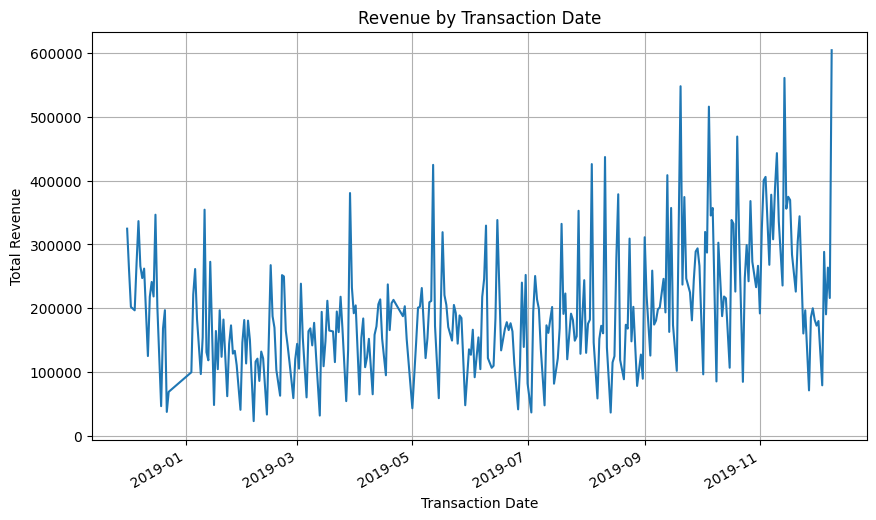

In [24]:
import matplotlib.pyplot as plt

# 1.2.3 Group by transaction_date and calculate the sum of revenue
revenue_by_date = df_pandas.groupby('transaction_date')['revenue'].sum()

# Plot the results
plt.figure(figsize=(10, 6))
revenue_by_date.plot(kind='line')
plt.title('Revenue by Transaction Date')
plt.xlabel('Transaction Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()


## Question 1.3

#### Let’s continue to analyse on the transaction_date vs revenue.

##### 1.3.1 Determine which workday (day of the week), generates the most sales (plotting the results in a line chart with workday on averaged revenues).

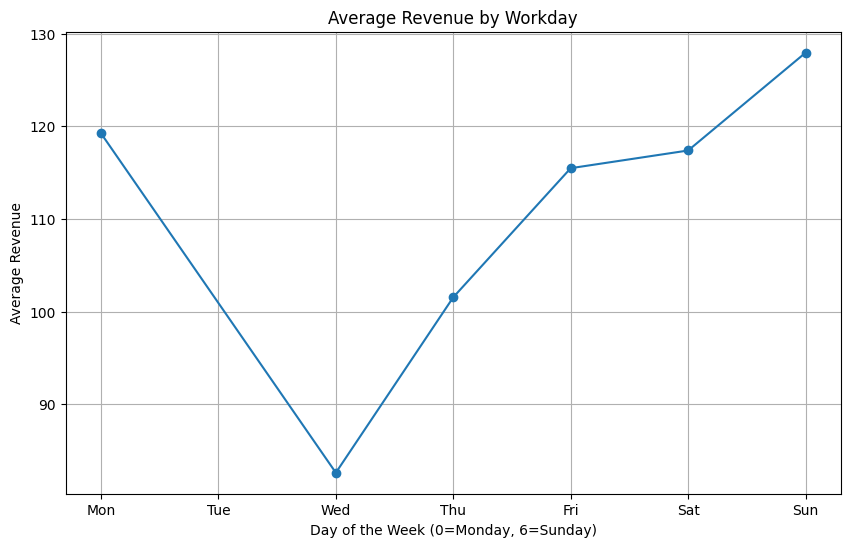

The workday with the highest average revenue is: 6


In [25]:


# Add a column for the weekday (0 = Monday, 6 = Sunday)
df_pandas['weekday'] = df_pandas['transaction_date'].dt.dayofweek

# Group by weekday and calculate average revenue
avg_revenue_by_weekday = df_pandas.groupby('weekday')['revenue'].mean()

# Plot the average revenue by weekday
plt.figure(figsize=(10, 6))
avg_revenue_by_weekday.plot(kind='line', marker='o')
plt.title('Average Revenue by Workday')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Revenue')
plt.grid(True)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

# Find the workday with the highest average revenue
best_workday = avg_revenue_by_weekday.idxmax()
print(f"The workday with the highest average revenue is: {best_workday}")


#### 1.3.2 Identify the name of product (column productName_process) that contributes the highest revenueon ‘that workday’ (you need to find out from 1.3.1) and the name of product (column productName_process) that has the highest sales volume (sum of the Quantity), no need to remove negative quantity transactions.) on ‘that workday’ (you need to find out from 1.3.1).

In [26]:
# Filter data for transactions occurring on the best workday
df_best_workday = df_pandas[df_pandas['weekday'] == best_workday]

# 1.3.2 Find the product with the highest revenue on that workday
product_highest_revenue = df_best_workday.groupby('productName_process')['revenue'].sum().idxmax()
highest_revenue_value = df_best_workday.groupby('productName_process')['revenue'].sum().max()

# 1.3.2 Find the product with the highest sales volume (sum of Quantity) on that workday
product_highest_volume = df_best_workday.groupby('productName_process')['Quantity'].sum().idxmax()
highest_volume_value = df_best_workday.groupby('productName_process')['Quantity'].sum().max()

print(f"The product with the highest revenue on the best workday is: {product_highest_revenue} with revenue {highest_revenue_value}")
print(f"The product with the highest sales volume on the best workday is: {product_highest_volume} with quantity {highest_volume_value}")

The product with the highest revenue on the best workday is: WorldWarGlidersAsstdDesigns with revenue 187081.34375
The product with the highest sales volume on the best workday is: WorldWarGlidersAsstdDesigns with quantity 18051


#### 1.3.3 Please provide two plots showing the top 5 products that contribute the highest revenues in general and top 5 products that have the highest sales volumes in general.

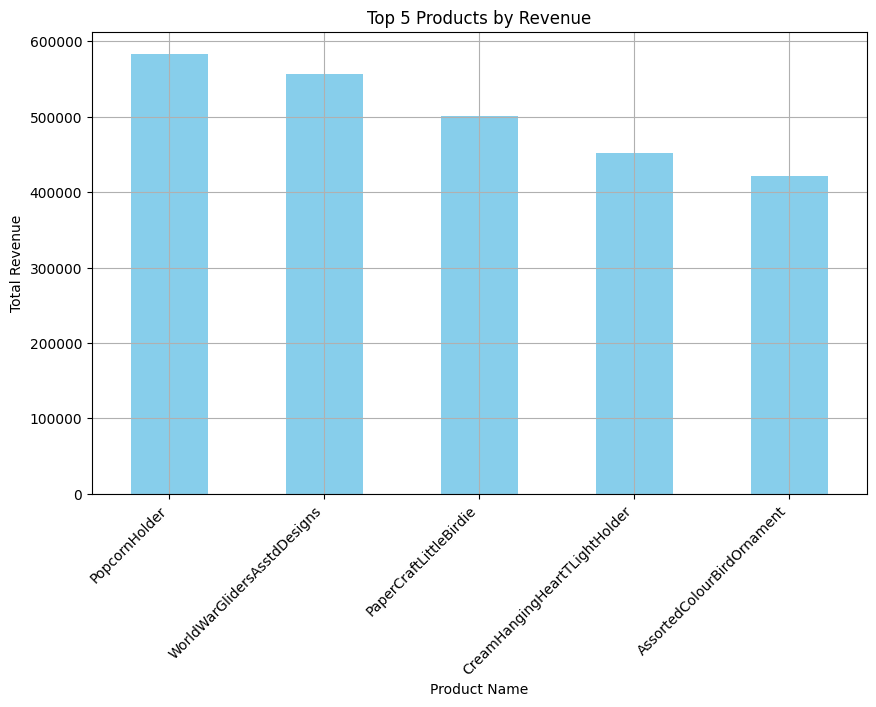

In [27]:
# 1.3.3 Top 5 products with the highest revenues in general
top_5_products_revenue = df_pandas.groupby('productName_process')['revenue'].sum().nlargest(5)

# Plotting the top 5 products by revenue
plt.figure(figsize=(10, 6))
top_5_products_revenue.plot(kind='bar', color='skyblue')
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.show()





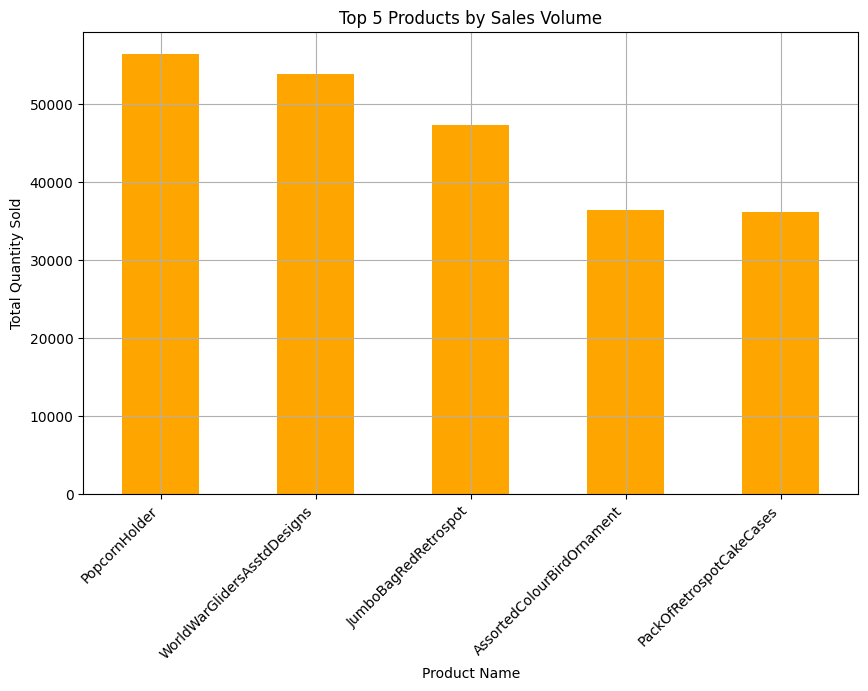

In [28]:
# 1.3.3 Top 5 products with the highest sales volumes in general
top_5_products_volume = df_pandas.groupby('productName_process')['Quantity'].sum().nlargest(5) # Changed 'quantity' to 'Quantity'

# Plotting the top 5 products by sales volume
plt.figure(figsize=(10, 6))
top_5_products_volume.plot(kind='bar', color='orange')
plt.title('Top 5 Products by Sales Volume')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.show()

## Question 1.4

####  Which country generates the highest revenue? Additionally, identify the month in that country that has the highest revenue.


The country with the highest revenue is: United Kingdom with total revenue of 49994032.0
The month with the highest revenue in United Kingdom is: 11 with total revenue of 6737640.0


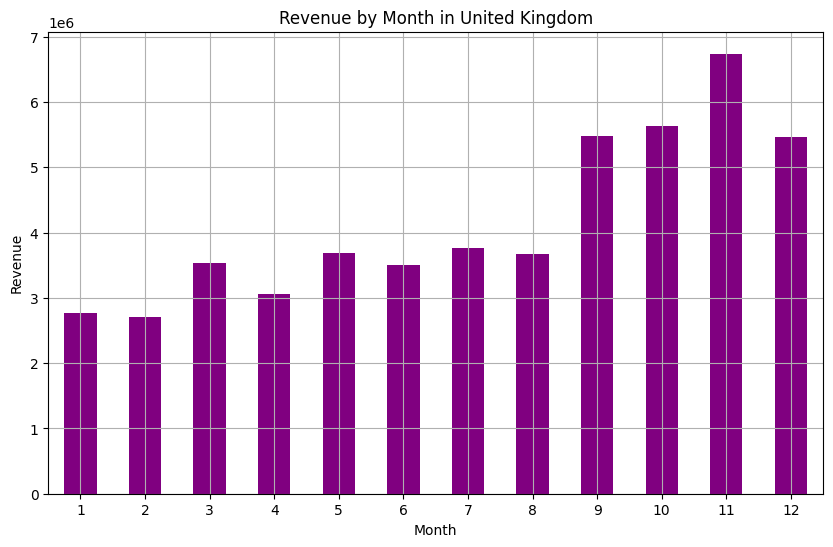

In [29]:
# 1.4 Find the country that generates the highest revenue
country_revenue = df_pandas.groupby('Country')['revenue'].sum()
top_country = country_revenue.idxmax()
top_country_revenue = country_revenue.max()

print(f"The country with the highest revenue is: {top_country} with total revenue of {top_country_revenue}")

# 2. Filter data for the top country
df_top_country = df_pandas[df_pandas['Country'] == top_country]

# 3. Extract month from 'transaction_date' and create a new column 'month'
df_top_country['month'] = df_top_country['transaction_date'].dt.month

# 4. Group by month and calculate the revenue for each month
monthly_revenue_top_country = df_top_country.groupby('month')['revenue'].sum()

# Find the month with the highest revenue
top_month = monthly_revenue_top_country.idxmax()
top_month_revenue = monthly_revenue_top_country.max()

print(f"The month with the highest revenue in {top_country} is: {top_month} with total revenue of {top_month_revenue}")

# Plotting the monthly revenue for the top country
plt.figure(figsize=(10, 6))
monthly_revenue_top_country.plot(kind='bar', color='purple')
plt.title(f'Revenue by Month in {top_country}')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=0)
plt.show()


## Question 1.5

#### Let’s do some analysis on the CustomerNo and their transactions. Determine the shopping frequency of customers to identify who shops most frequently (find out the highest distinct count of transactionNo on customer level, be careful with those transactions that is not for shopping – filter those transaction quantity <= 0). Also, find out what products (column productName_process) ‘this customer’ typically buys based on the Quantity of products purchased.

In [30]:
print(df_pandas.columns)


Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Product_category',
       'Price', 'Quantity', 'CustomerNo', 'Country', 'productName_process',
       'revenue', 'transaction_date', 'weekday'],
      dtype='object')


In [31]:
import pandas as pd

# Load the CSV file (assuming it's loaded into df_pandas earlier)
# df_pandas = pd.read_csv('your_file.csv')

# Filter out transactions where quantity is less than or equal to 0 (non-shopping transactions)
shopping_data = df_pandas[df_pandas['Quantity'] > 0]

# Group data by CustomerNo and calculate the number of distinct transactions
customer_transaction_freq = shopping_data.groupby('CustomerNo')['TransactionNo'].nunique().reset_index()

# Find the customer with the highest number of distinct transactions
most_frequent_customer = customer_transaction_freq.sort_values(by='TransactionNo', ascending=False).iloc[0]

# Get CustomerNo of the most frequent shopper
top_customer_no = most_frequent_customer['CustomerNo']

# Find the products that this customer typically buys, based on the quantity of products purchased
top_customer_products = shopping_data[shopping_data['CustomerNo'] == top_customer_no].groupby('ProductName').agg({'Quantity': 'sum'}).reset_index()

# Sort the products by quantity in descending order
top_customer_products = top_customer_products.sort_values(by='Quantity', ascending=False)

# Results
print(f"Most Frequent CustomerNo: {top_customer_no}")
print(f"Number of Distinct Transactions: {most_frequent_customer['TransactionNo']}")
print("\nTop Products Purchased by this Customer:")
print(top_customer_products.head())


Most Frequent CustomerNo: 12748
Number of Distinct Transactions: 207

Top Products Purchased by this Customer:
                            ProductName  Quantity
1629    Victorian Metal Postcard Spring       595
1724  World War 2 Gliders Asstd Designs       480
1301  Rose Scent Candle Jewelled Drawer       408
265           Cartoon Pencil Sharpeners       405
1511   Small White Retrospot Mug In Box       390


In [32]:
# Find the products that this customer typically buys, based on the quantity of products purchased
# Changed back to 'ProductName_process' for processed product names
top_customer_products = shopping_data[shopping_data['CustomerNo'] == top_customer_no].groupby('productName_process').agg({'Quantity': 'sum'}).reset_index()

# Sort the products by quantity in descending order
top_customer_products = top_customer_products.sort_values(by='Quantity', ascending=False)


In [33]:
# Filter out transactions where quantity is less than or equal to 0 (non-shopping transactions)
shopping_data = df_pandas[df_pandas['Quantity'] > 0] # Changed 'transaction_data' to 'df_pandas'

# Group data by CustomerNo and calculate the number of distinct transactions
customer_transaction_freq = shopping_data.groupby('CustomerNo')['TransactionNo'].nunique().reset_index()

# Find the customer with the highest number of distinct transactions
most_frequent_customer = customer_transaction_freq.sort_values(by='TransactionNo', ascending=False).iloc[0]

# Get CustomerNo of the most frequent shopper
top_customer_no = most_frequent_customer['CustomerNo']

# Find the products that this customer typically buys, based on the quantity of products purchased
# Changed 'ProductName_process' to 'ProductName'
top_customer_products = shopping_data[shopping_data['CustomerNo'] == top_customer_no].groupby('productName_process').agg({'Quantity': 'sum'}).reset_index()

# Sort the products by quantity in descending order
top_customer_products = top_customer_products.sort_values(by='Quantity', ascending=False)

# Results
print(f"Most Frequent CustomerNo: {top_customer_no}")
print(f"Number of Distinct Transactions: {most_frequent_customer['TransactionNo']}")
print("\nTop Products Purchased by this Customer:")
print(top_customer_products.head())

Most Frequent CustomerNo: 12748
Number of Distinct Transactions: 207

Top Products Purchased by this Customer:
                productName_process  Quantity
1609   VictorianMetalPostcardSpring       595
1706    WorldWarGlidersAsstdDesigns       480
1273  RoseScentCandleJewelledDrawer       408
201         CartoonPencilSharpeners       405
1483    SmallWhiteRetrospotMugInBox       390


## Question 1.6

#### As the data scientist, you would like to build a basket-level analysis on the product customer buying (filter the ‘df’ dataframe with df[’Quantity’]>0). In this task, you need to:
#### 1.6.1 Group by the transactionNo and aggregate the category of product (column product_category) into list on transactionNo level. Similarly, group and aggregate name of product (column productName_process) into list on transactionNo level.

In [34]:
# Step 1.6.1: Filter out non-shopping transactions (Quantity > 0)
df_filtered = df_pandas[df_pandas['Quantity'] > 0]

# Group by TransactionNo and aggregate product_category and ProductName into lists
df_grouped = df_filtered.groupby('TransactionNo').agg({
    'Product_category': lambda x: list(x),
    'productName_process': lambda x: list(x)
}).reset_index()

#### 1.6.2 Removing duplicates on adjacent elements in the list from product_category you obtained from 1.6.1, such as [product category 1, product category 1, product category 2, ...] will be processed as [product category 1, product category 2,....]. After this processing, there will be no duplicates on on adjacent elements in the list. Please save your processed dataframe as ‘df_1’ and print the top 10 rows.

In [35]:
# Step 1.6.2: Function to remove adjacent duplicates from lists
def remove_adjacent_duplicates(lst):
    return [v for i, v in enumerate(lst) if i == 0 or v != lst[i-1]]

# Apply the function to the product_category list
df_grouped['Product_category'] = df_grouped['Product_category'].apply(remove_adjacent_duplicates)

# Save the processed DataFrame as 'df_1' and print the top 10 rows
df_1 = df_grouped
print(df_1.head(10))

  TransactionNo Product_category  \
0        536365            [0ca]   
1        536366            [0ca]   
2        536367            [0ca]   
3        536368            [0ca]   
4        536369            [0ca]   
5        536370            [0ca]   
6        536371            [0ca]   
7        536372            [0ca]   
8        536373            [0ca]   
9        536374            [0ca]   

                                 productName_process  
0  [CreamHangingHeartTLightHolder, WhiteMoroccanM...  
1      [HandWarmerUnionJack, HandWarmerRedRetrospot]  
2  [AssortedColourBirdOrnament, PoppysPlayhouseBe...  
3  [JamMakingSetWithJars, RedCoatRackParisFashion...  
4                            [BathBuildingBlockWord]  
5  [AlarmClockBakelikePink, AlarmClockBakelikeRed...  
6                          [PaperChainKitSChristmas]  
7      [HandWarmerRedRetrospot, HandWarmerUnionJack]  
8  [CreamHangingHeartTLightHolder, WhiteMoroccanM...  
9                          [VictorianSewingBoxLarge] 

## Question 1.7
#### Continue work on the results of question 1.6, now for each of the transaction, you will have a list of product categories. To further conduct the analysis, you need to finish below by using dataframe‘df_1’:

### 1.7.1 Create new column prod_len to find out the length of the list from product_category on each transaction. Print the first five rows of dataframe ‘df_1’.

In [36]:
# Define the data_processing function
def data_processing(df, maxlength=3, minlength=1):
    # Create 'prod_len' column to find out the length of the list from product_category
    df['prod_len'] = df['Product_category'].apply(len)

    # Create the 'path' column by transforming the list in 'Product_category'
    df['path'] = df['Product_category'].apply(lambda x: 'start > ' + ' > '.join(x) + ' > conversion')

    # Filter the dataframe based on the 'prod_len' column with maxlength and minlength constraints
    df_filtered = df[(df['prod_len'] <= maxlength) & (df['prod_len'] >= minlength)]

    # Return the filtered dataframe
    return df_filtered



# Create the 'prod_len' column and display the first 5 rows of df_1
df_1['prod_len'] = df_1['Product_category'].apply(len)
print("First 5 rows of df_1 with 'prod_len' column:")
print(df_1.head(5))



First 5 rows of df_1 with 'prod_len' column:
  TransactionNo Product_category  \
0        536365            [0ca]   
1        536366            [0ca]   
2        536367            [0ca]   
3        536368            [0ca]   
4        536369            [0ca]   

                                 productName_process  prod_len  
0  [CreamHangingHeartTLightHolder, WhiteMoroccanM...         1  
1      [HandWarmerUnionJack, HandWarmerRedRetrospot]         1  
2  [AssortedColourBirdOrnament, PoppysPlayhouseBe...         1  
3  [JamMakingSetWithJars, RedCoatRackParisFashion...         1  
4                            [BathBuildingBlockWord]         1  


#### 1.7.2 Transform the list in product_category from [productcategory1, productcategory2...] to ‘start > productcategory1 > productcategory2 > ... > conversion’ with new column path. You need to add ‘start’ as the first element, and ‘conversion’ as the last. Also you need to use ‘ > ’ to connect each of the transition on products (there is a space between the elements and the transition symbol >). The final format after the transition is given in example as below fig. 2. Define the function data_processing to achieve above with three arguments: df which is the dataframe name, maxlength with default value of 3 for filtering the dataframe with prod_len" <=maxlength and minlength with default value of 1 for filtering the dataframe with prod_len >=minlength. The function data_processing will return the new dataframe ‘df_2’. Run your defined function with dataframe ‘df_1’, maxlength = 5 and minlength = 2, print the dataframe ‘df_2’ with top 10 rows.


In [37]:
# we Ensure df_1 is available and contains the necessary 'Product_category' list

#  Define the data_processing function
def data_processing(df, maxlength=3, minlength=1):
    # Create 'path' column by transforming the list in 'Product_category'
    # Add 'start' at the beginning and 'conversion' at the end of the path
    df['path'] = df['Product_category'].apply(lambda x: 'start > ' + ' > '.join(x) + ' > conversion')

    # Create 'prod_len' column to calculate the length of 'Product_category'
    df['prod_len'] = df['Product_category'].apply(len)

    # Filter the dataframe based on 'prod_len' column with maxlength and minlength constraints
    df_filtered = df[(df['prod_len'] <= maxlength) & (df['prod_len'] >= minlength)]

    # Return the filtered dataframe
    return df_filtered

# Step 3: Run the defined function with df_1, maxlength=5 and minlength=2
df_2 = data_processing(df_1, maxlength=5, minlength=2)

# Step 4: Print the top 10 rows of the dataframe df_2
print("Top 10 rows of df_2 with 'path' and filtered by 'prod_len':")
print(df_2.head(10))


Top 10 rows of df_2 with 'path' and filtered by 'prod_len':
   TransactionNo           Product_category  \
13        536378            [0ca, 1ca, 0ca]   
27        536395            [0ca, 1ca, 0ca]   
36        536404  [0ca, 1ca, 0ca, 4ca, 0ca]   
40        536408            [0ca, 1ca, 0ca]   
42        536412            [0ca, 4ca, 0ca]   
43        536415            [0ca, 1ca, 0ca]   
52        536464            [0ca, 1ca, 0ca]   
72        536532            [0ca, 1ca, 0ca]   
82        536542                 [0ca, 4ca]   
83        536544  [0ca, 1ca, 0ca, 4ca, 0ca]   

                                  productName_process  prod_len  \
13  [StrawberryCharlotteBag, ChildrensCutleryRetro...         3   
27  [BlackHeartCardHolder, AssortedColourBirdOrnam...         3   
36  [HeartIvoryTrellisSmall, ClearDrawerKnobAcryli...         5   
40  [MagicDrawingSlateDinosaur, MagicDrawingSlateB...         3   
42  [RoundSnackBoxesSetOfWoodland, RoundSnackBoxes...         3   
43  [CakeCasesVintag

## Question 1.8
#### Continue to work on the results of question 1.7, the dataframe ‘df_2’, we would like to build the transition matrix together, but before we actually conduct the programming, we will need to finish few questions for exploration:

#### 1.8.1 Check on your transaction level basket with results from question 1.7, could you please find out respectively how many transactions ended with pattern ‘... > 0ca > conversion’ / ‘...> 1ca > conversion’ / ‘... > 2ca > conversion’ / ‘... > 3ca > conversion’ / ‘... > 4ca > conversion’ (1 result for each pattern, total 5 results are expected).


In [38]:
# Define the patterns to search for
patterns = ['> 0ca > conversion', '> 1ca > conversion', '> 2ca > conversion', '> 3ca > conversion', '> 4ca > conversion']

# Find how many transactions end with each pattern
for pattern in patterns:
    count = df_2[df_2['path'].str.endswith(pattern)].shape[0]
    print(f"Transactions ending with '{pattern}': {count}")


Transactions ending with '> 0ca > conversion': 3056
Transactions ending with '> 1ca > conversion': 26
Transactions ending with '> 2ca > conversion': 144
Transactions ending with '> 3ca > conversion': 68
Transactions ending with '> 4ca > conversion': 198


#### 1.8.2 Check on your transaction level basket with results from question 1.7, could you please find out respectively how many times the transactions contains ‘0ca > 0ca’ / ‘0ca > 1ca’ / ‘0ca > 2ca’ / ‘0ca > 3ca’ / ‘0ca > 4ca’ / ‘0ca > conversion’ in the whole data (1 result for each pattern, total 6 results are expected and each transaction could contain those patterns multiple times, such as ‘start > 0ca > 1ca > 0ca > 1ca > conversion’ will count ‘two’ times with pattern ‘0ca > 1ca’, if there is not any, then return 0, you need to sum the counts from each transaction to return the final value).


In [39]:
# Define the patterns to search for
patterns = ['0ca > 0ca', '0ca > 1ca', '0ca > 2ca', '0ca > 3ca', '0ca > 4ca', '0ca > conversion']

# Loop through each pattern and sum up the occurrences in the 'path' column
for pattern in patterns:
    count = df_2['path'].str.count(pattern).sum()
    print(f"Occurrences of pattern '{pattern}': {count}")


Occurrences of pattern '0ca > 0ca': 0
Occurrences of pattern '0ca > 1ca': 1222
Occurrences of pattern '0ca > 2ca': 1137
Occurrences of pattern '0ca > 3ca': 343
Occurrences of pattern '0ca > 4ca': 1198
Occurrences of pattern '0ca > conversion': 3056


#### 1.8.3 Check on your transaction level basket with results from task question 1.7, could you please find out how many times the transactions contains ‘...> 0ca > ...’ in the whole data (1 result is expected and each transaction could contain the pattern multiple times, such as ‘start > 0ca > 1ca > 0ca > 1ca > conversion’ will count ‘two’ times, you need to sum the counts from each transaction to return the final value).

In [40]:
# Define the pattern to search for
pattern = ' > 0ca > '

# Count the occurrences of the pattern in the 'path' column across all transactions
count = df_2['path'].str.count(pattern).sum()

# Print the result
print(f"Occurrences of pattern '{pattern}': {count}")


Occurrences of pattern ' > 0ca > ': 6956


#### 1.8.4 Use the 6 results from 1.8.2 to divide the result from 1.8.3 and then sum all of them and return the value.

In [41]:
# Define the patterns from 1.8.2
patterns_1_8_2 = ['0ca > 0ca', '0ca > 1ca', '0ca > 2ca', '0ca > 3ca', '0ca > 4ca', '0ca > conversion']

# Calculate the occurrences for each pattern in 1.8.2
counts_1_8_2 = [df_2['path'].str.count(pattern).sum() for pattern in patterns_1_8_2]

# Get the result from 1.8.3 (occurrences of ' > 0ca > ' pattern)
count_1_8_3 = df_2['path'].str.count(' > 0ca > ').sum()

# Calculate the result by dividing each count from 1.8.2 by the result of 1.8.3
if count_1_8_3 != 0:  # Avoid division by zero
    result = sum([count / count_1_8_3 for count in counts_1_8_2])
else:
    result = 0  # If there are no ' > 0ca > ' patterns

# Print the final result
print(f"Final result: {result}")


Final result: 1.0


## Question 1.9

#### Let’s now look at the question 1.6 again, you have the list of product and list of product category for each transaction. We will use the transactionNo and productName_process to conduct the Association rule learning.

#### 1.9.1 Work on the dataframe df from question 1.2 (filter out the transaction with negative quantity value and also only keep those top 100 products by ranking the sum of quantity) and build the transaction level product dataframe (each row represents transactionNo and productName_process become the columns, the value in the column is the Quantity). Hint: you might consider to use pivot function in pandas.

In [42]:
# Step 1: Filter out transactions with negative quantity values
df_filtered = df_pandas[df_pandas['Quantity'] > 0]

# Step 2: Get the top 100 products by total quantity sold
# Check if the column name is 'ProductName' and not 'ProductName_process'
top_products = df_filtered.groupby('productName_process')['Quantity'].sum().nlargest(100).index

# Step 3: Filter the dataframe to only keep these top 100 products
df_top_products = df_filtered[df_filtered['productName_process'].isin(top_products)]

# Step 4: Create a transaction-level product matrix using pivot_table
transaction_product_df = df_top_products.pivot_table(
    index='TransactionNo',
    columns='productName_process', # Use 'productName_process' here as well
    values='Quantity',
    aggfunc='sum',
    fill_value=0  # Fill NaN with 0 as the product was not bought in that transaction
)

# Print the first few rows of the transaction-level product dataframe
print(transaction_product_df.head())

productName_process  AgedGlassSilverTLightHolder  AntiqueSilverTLightGlass  \
TransactionNo                                                                
536365                                         0                         0   
536367                                         0                         0   
536370                                         0                         0   
536371                                         0                         0   
536373                                         0                         0   

productName_process  AssortedColourBirdOrnament  AssortedColoursSilkFan  \
TransactionNo                                                             
536365                                        0                       0   
536367                                       32                       0   
536370                                        0                       0   
536371                                        0                       0   
536

###1.9.2 Run the apriori algorithm to identify items with minimum support of 1.5% (only looking at baskets with 4 or more items).
####Hint: you might consider to use mlxtend.frequent_patterns to run apriori rules.

In [43]:
# 1.9.2 Filter transactions with 4 or more items (sum of quantities >= 4)
transaction_product_df['num_items'] = transaction_product_df.gt(0).sum(axis=1)
transaction_product_df_filtered = transaction_product_df[transaction_product_df['num_items'] >= 4].drop(columns=['num_items'])
from mlxtend.frequent_patterns import apriori, association_rules
# Convert the DataFrame to a one-hot encoded DataFrame
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

transaction_product_df_filtered = transaction_product_df_filtered.applymap(encode_units)

frequent_itemsets = apriori(transaction_product_df_filtered, min_support=0.015, use_colnames=True)

# Print the frequent itemsets found
print(frequent_itemsets)

/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


       support                                           itemsets
0     0.031276                      (AgedGlassSilverTLightHolder)
1     0.085835                         (AntiqueSilverTLightGlass)
2     0.126928                       (AssortedColourBirdOrnament)
3     0.054698                           (AssortedColoursSilkFan)
4     0.057083                                (BaggSwirlyMarbles)
...        ...                                                ...
4367  0.015989  (StrawberryCharlotteBag, RedRetrospotCharlotte...
4368  0.015147  (LunchBagSpaceboyDesign, LunchBagPinkPolkadot,...
4369  0.015428  (LunchBagPinkPolkadot, LunchBagSukiDesign, Lun...
4370  0.015288  (LunchBagSpaceboyDesign, LunchBagSukiDesign, L...
4371  0.015147  (LunchBagSpaceboyDesign, LunchBagPinkPolkadot,...

[4372 rows x 2 columns]


##### 1.9.3 Run the apriori algorithm to find the items with support >= 1.0% and lift > 10.

In [44]:
# 1.9.3 Filter transactions with 4 or more items (sum of quantities >= 4)
transaction_product_df['num_items'] = transaction_product_df.gt(0).sum(axis=1)
transaction_product_df_filtered = transaction_product_df[transaction_product_df['num_items'] >= 4].drop(columns=['num_items'])

# Print the frequent itemsets found
print(frequent_itemsets)

       support                                           itemsets
0     0.031276                      (AgedGlassSilverTLightHolder)
1     0.085835                         (AntiqueSilverTLightGlass)
2     0.126928                       (AssortedColourBirdOrnament)
3     0.054698                           (AssortedColoursSilkFan)
4     0.057083                                (BaggSwirlyMarbles)
...        ...                                                ...
4367  0.015989  (StrawberryCharlotteBag, RedRetrospotCharlotte...
4368  0.015147  (LunchBagSpaceboyDesign, LunchBagPinkPolkadot,...
4369  0.015428  (LunchBagPinkPolkadot, LunchBagSukiDesign, Lun...
4370  0.015288  (LunchBagSpaceboyDesign, LunchBagSukiDesign, L...
4371  0.015147  (LunchBagSpaceboyDesign, LunchBagPinkPolkadot,...

[4372 rows x 2 columns]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 1.9.4 Please explore three more examples with different support / confidence / lift measurements (you could leverage your rule mining with one of the three measurements or all of them) to find out any of the interesting patterns from the Association rule learning. Save your code and results in a clean and tidy format and writing down your insights.

In [45]:
# 1.9.4: Support >= 0.005 and Confidence >= 0.6
rules_exp1 = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
print("Example 1 - Support >= 0.005 and Confidence >= 0.6:")
print(rules_exp1)

# 1.9.4: Support >= 0.02 and Lift >= 8
rules_exp2 = association_rules(frequent_itemsets, metric="lift", min_threshold=8)
print("Example 2 - Support >= 0.02 and Lift >= 8:")
print(rules_exp2)

# 1.9.4: Support >= 0.01 and Confidence >= 0.8
rules_exp3 = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)
print("Example 3 - Support >= 0.01 and Confidence >= 0.8:")
print(rules_exp3)

Example 1 - Support >= 0.005 and Confidence >= 0.6:
                                            antecedents  \
0                            (CharlotteBagPinkPolkadot)   
1                              (CharlotteBagSukiDesign)   
2                                    (SpaceboyLunchBox)   
3                                   (DollyGirlLunchBox)   
4                           (JumboBagBaroqueBlackWhite)   
...                                                 ...   
4890  (LunchBagSukiDesign, LunchBagPinkPolkadot, Lun...   
4891  (LunchBagRedRetrospot, LunchBagSukiDesign, Lun...   
4892  (LunchBagWoodland, LunchBagPinkPolkadot, Lunch...   
4893  (LunchBagSukiDesign, LunchBagWoodland, LunchBa...   
4894  (LunchBagSukiDesign, LunchBagWoodland, LunchBa...   

                                         consequents  antecedent support  \
0                         (RedRetrospotCharlotteBag)            0.098177   
1                         (RedRetrospotCharlotteBag)            0.113324   
2          

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Example 2 - Support >= 0.02 and Lift >= 8:
                                            antecedents  \
0                    (WoodenHeartChristmasScandinavian)   
1                     (WoodenStarChristmasScandinavian)   
2     (GinAndTonicDietMetalSign, PleaseOnePersonMeta...   
3                               (CookWithWineMetalSign)   
4     (PaperChainKitSChristmas, PackOfRetrospotCakeC...   
...                                                 ...   
4513           (LunchBagWoodland, LunchBagPinkPolkadot)   
4514             (LunchBagSukiDesign, LunchBagWoodland)   
4515               (LunchBagWoodland, LunchBagCarsBlue)   
4516           (LunchBagRedRetrospot, LunchBagWoodland)   
4517           (LunchBagRedRetrospot, LunchBagCarsBlue)   

                                            consequents  antecedent support  \
0                     (WoodenStarChristmasScandinavian)            0.054979   
1                    (WoodenHeartChristmasScandinavian)            0.053296   
2          

## Question 1.10

#### After we finished the Association rule learning, it is a time for us to consider to do customer analysis based on their shopping behaviours.

#### 1.10.1 Work on the dataframe df from question 1.2 and build the customer product dataframe (each row represents single customerNo and productName_process become as the columns, the value in the columns is the aggregated Quantity value from all transactions and the result is a N by M matrix where N is the number of distinct customerNo and M is the number of distinct productName_process. Please filter out the transaction with negative quantity value and also only keep those top 100 product by ranking the sum of quantity).

In [46]:
# 1.10.1 Filter out transactions with negative quantity
df_filtered = df[df['Quantity'] > 0]

# Group by 'CustomerNo' and 'productName_process' and aggregate the sum of 'Quantity'
df_grouped = df_filtered.groupBy(['CustomerNo', 'productName_process']).agg({'Quantity': 'sum'})

# Rename the aggregated column for clarity
df_grouped = df_grouped.withColumnRenamed('sum(Quantity)', 'Quantity_sum')


# Group by 'productName_process' and aggregate the sum of 'Quantity'
df_product_quantity = df_grouped.groupBy('productName_process').agg({'Quantity_sum': 'sum'})

# Rename the aggregated column for clarity
df_product_quantity = df_product_quantity.withColumnRenamed('sum(Quantity_sum)', 'total_quantity')

print(df_product_quantity.show(5))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


+--------------------+--------------+
| productName_process|total_quantity|
+--------------------+--------------+
|   DollyGirlLunchBox|         11802|
|ZincWillieWinkieC...|          2935|
|GentlemanShirtRep...|          2166|
|ToastItsHappyBirt...|           412|
|   FoilStarCakeCases|          1192|
+--------------------+--------------+
only showing top 5 rows

None


In [47]:
# Group by 'CustomerNo' and 'productName_process' and aggregate the sum of 'Quantity'
df_grouped = df_filtered.groupBy(['CustomerNo', 'productName_process']).agg({'Quantity': 'sum'})

# Rename the aggregated column for clarity
df_grouped = df_grouped.withColumnRenamed('sum(Quantity)', 'Quantity_sum')

# Show the top rows
df_grouped.show(5)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


+----------+--------------------+------------+
|CustomerNo| productName_process|Quantity_sum|
+----------+--------------------+------------+
|     15492|MiniPlayingCardsS...|           1|
|     15492|EggCupHenriettaHe...|           1|
|     15492|RotatingLeavesTLi...|          11|
|     15492| BanquetBirthdayCard|           4|
|     15492|WoodlandCharlotteBag|           7|
+----------+--------------------+------------+
only showing top 5 rows



In [48]:
# Group by 'productName_process' and aggregate the sum of 'Quantity'
df_product_quantity = df_grouped.groupBy('productName_process').agg({'Quantity_sum': 'sum'})

# Rename the aggregated column for clarity
df_product_quantity = df_product_quantity.withColumnRenamed('sum(Quantity_sum)', 'total_quantity')

# Show the top rows
df_product_quantity.show(5)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


+--------------------+--------------+
| productName_process|total_quantity|
+--------------------+--------------+
|   DollyGirlLunchBox|         11802|
|ZincWillieWinkieC...|          2935|
|GentlemanShirtRep...|          2166|
|ToastItsHappyBirt...|           412|
|   FoilStarCakeCases|          1192|
+--------------------+--------------+
only showing top 5 rows



#### 1.10.2 Use the customer-product dataframe, let’s calculate the Pairwise Euclidean distance on customer level (you will need to use the product Quantity information on each customer to calculate the Euclidean distance for all other customers and the result is a N by N matrix where N is the number of distinct customerNo).

In [49]:
from pyspark.sql import functions as F

# Aggregate the quantity by CustomerNo and productName_process (ignoring negative quantities)
df_grouped = df_filtered.filter(df_filtered['Quantity'] > 0) \
    .groupBy('CustomerNo', 'productName_process') \
    .agg(F.sum('Quantity').alias('Total_Quantity'))

# Pivot the table to create a customer-product matrix
customer_product_matrix = df_grouped.groupBy('CustomerNo') \
    .pivot('productName_process') \
    .sum('Total_Quantity') \
    .fillna(0)  # Replace missing values with 0

# Show the first few rows of the customer-product matrix
customer_product_matrix.show(5)



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


+----------+-------------------+-------------------+-------------------+------------------+---------------------+-------------------------+-------------------------+--------------------+-----------------------+-----------------------+---------------------+----------------------+----------------------+-------------------------+----------------------+-------------------------+---------------------+---------------------------+----------------------------+--------------------------+----------------------------+----------------------+------------------------------+----------------------+---------------------------+-----------------------+-----------------------+------------------------+----------------------+---------------------+--------------------------+--------------------+---------------------+---------------------+----------------------------+---------------------------+-----------------------------+----------------------------+------------------------+---------------------------+----

In [50]:
from scipy.spatial.distance import pdist, squareform
# Convert the Spark DataFrame to a Pandas DataFrame for distance calculation
customer_product_pandas = customer_product_matrix.toPandas()

# Set CustomerNo as the index
customer_product_pandas.set_index('CustomerNo', inplace=True)
from scipy.spatial.distance import pdist, squareform

# Calculate pairwise Euclidean distances
distances = pdist(customer_product_pandas, metric='euclidean')

# Convert the distances into a square matrix
distance_matrix = squareform(distances)

# Convert to a Pandas DataFrame for easier access
distance_df = pd.DataFrame(distance_matrix, index=customer_product_pandas.index, columns=customer_product_pandas.index)

# Show the distance matrix
distance_df.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):
/usr/local/lib/python3.10/dist-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):


CustomerNo,15555,17686,18130,13772,16974,12847,14204,13610,16504,15271,...,18080,16323,15316,17440,16699,12814,16387,15649,15040,17763
CustomerNo,,,,,,,,,,,,,,,,,,,,,
15555,0.000000,422.005924,383.018276,373.032170,366.907345,396.872776,369.254655,375.442406,374.645165,389.518934,...,584.900846,372.592270,382.785841,407.883562,369.482070,372.597638,369.795890,416.400048,369.541608,369.622781
17686,422.005924,0.000000,261.419204,235.138257,232.430635,283.045933,235.431519,240.299813,246.381818,261.315901,...,511.413727,238.746728,251.594913,291.794448,235.061694,240.008333,236.753036,303.585243,235.236052,235.465496
18130,383.018276,261.419204,0.000000,147.790392,137.767921,207.308948,135.919094,157.321327,150.698374,200.823305,...,473.715104,143.742826,167.815375,219.102716,134.877722,136.886815,137.528179,234.576214,134.899963,135.299667
13772,373.032170,235.138257,147.790392,0.000000,68.760454,170.994152,64.187226,97.826377,111.821286,158.933949,...,454.849426,67.409198,118.084715,183.815125,63.039670,79.044291,68.527367,202.009901,63.087241,63.937469
16974,366.907345,232.430635,137.767921,68.760454,0.000000,163.948163,39.344631,87.487142,98.000000,150.970196,...,455.475576,60.116553,104.947606,176.232801,35.242020,58.497863,43.794977,195.135850,35.355339,36.851052


### 1.10.3 Use the customer Pairwise Euclidean distance to find out the top 3 most similar customer to CustomerNo == 13069 and CustomerNo == 17490.

In [51]:
# 1.10.3 Check if CustomerNo 13069 exists in the filtered DataFrame
customer_exists = df_filtered.filter(df_filtered['CustomerNo'] == 13069).count() > 0

print(customer_exists)

# Check if CustomerNo 13069 exists in the DataFrame
print(13069 in distance_df.index)

# Check all transactions for CustomerNo 13069
customer_13069_data = df[df['CustomerNo'] == 13069]
print(customer_13069_data)

# Filter out negative quantities
df_filtered_positive = df_filtered.filter(df_filtered['Quantity'] > 0)

# Import the functions module with the alias F
from pyspark.sql import functions as F

# Group by CustomerNo and productName_process, and sum the Quantity
df_grouped = df_filtered_positive.groupBy('CustomerNo', 'productName_process') \
    .agg(F.sum('Quantity').alias('Total_Quantity'))

# Show the grouped data
df_grouped.show(5)

# Pivot to create the customer-product matrix
customer_product_matrix = df_grouped.groupBy('CustomerNo') \
    .pivot('productName_process') \
    .sum('Total_Quantity') \
    .fillna(0)

# Show the customer-product matrix
customer_product_matrix.show(5)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


True
False
DataFrame[TransactionNo: string, Date: string, ProductNo: string, ProductName: string, Product_category: string, Price: double, Quantity: int, CustomerNo: string, Country: string, productName_process: string, revenue: float]
+----------+--------------------+--------------+
|CustomerNo| productName_process|Total_Quantity|
+----------+--------------------+--------------+
|     15492|MiniPlayingCardsS...|             1|
|     15492|EggCupHenriettaHe...|             1|
|     15492|RotatingLeavesTLi...|            11|
|     15492| BanquetBirthdayCard|             4|
|     15492|WoodlandCharlotteBag|             7|
+----------+--------------------+--------------+
only showing top 5 rows

+----------+-------------------+-------------------+-------------------+------------------+---------------------+-------------------------+-------------------------+--------------------+-----------------------+-----------------------+---------------------+----------------------+-------------------

In [52]:
# Convert to Pandas DataFrame
customer_product_pandas = customer_product_matrix.toPandas()

# Ensure that CustomerNo is set as the index
customer_product_pandas.set_index('CustomerNo', inplace=True)

# Check the first few rows to confirm CustomerNo is the index
print(customer_product_pandas.index)
customer_product_pandas.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):
/usr/local/lib/python3.10/dist-packages/pyspark/sql/pandas/utils.py:37: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(pandas.__version__) < LooseVersion(minimum_pandas_version):


Index(['15555', '17686', '18130', '13772', '16974', '12847', '14204', '13610',
       '16504', '15271',
       ...
       '18080', '16323', '15316', '17440', '16699', '12814', '16387', '15649',
       '15040', '17763'],
      dtype='object', name='CustomerNo', length=4719)


,APrettyThankYouCard,AWallTidyBlueOffice,AWallTidyRedFlowers,AbcTreasureBookBox,AbstractCircleJournal,AbstractCirclesPocketBook,AbstractCirclesSketchbook,AcrylicGeometricLamp,AcrylicHangingJewelBlue,AcrylicHangingJewelPink,...,cmMetalStringWithClips,dChristmasStampsStickers,dDogPicturePlayingCards,dHeartsHoneycombPaperGarland,dSheetOfCatStickers,dSheetOfDogStickers,dTraditionalChristmasStickers,dVintageChristmasStickers,pcWoodPlateSetDisposable,pcWoodenCutlerySetDisposable
CustomerNo,,,,,,,,,,,,,,,,,,,,,
15555,0,0,0,0,0,0,0,0,0,0,...,0,5,0,0,0,0,5,0,0,0
17686,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18130,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13772,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16974,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
from scipy.spatial.distance import pdist, squareform

# Calculate pairwise Euclidean distances
distances = pdist(customer_product_pandas, metric='euclidean')

# Convert the distances into a square matrix
distance_matrix = squareform(distances)

# Convert to a Pandas DataFrame for easier access
distance_df = pd.DataFrame(distance_matrix, index=customer_product_pandas.index, columns=customer_product_pandas.index)

# Check the distance DataFrame
distance_df.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


CustomerNo,15555,17686,18130,13772,16974,12847,14204,13610,16504,15271,...,18080,16323,15316,17440,16699,12814,16387,15649,15040,17763
CustomerNo,,,,,,,,,,,,,,,,,,,,,
15555,0.000000,422.005924,383.018276,373.032170,366.907345,396.872776,369.254655,375.442406,374.645165,389.518934,...,584.900846,372.592270,382.785841,407.883562,369.482070,372.597638,369.795890,416.400048,369.541608,369.622781
17686,422.005924,0.000000,261.419204,235.138257,232.430635,283.045933,235.431519,240.299813,246.381818,261.315901,...,511.413727,238.746728,251.594913,291.794448,235.061694,240.008333,236.753036,303.585243,235.236052,235.465496
18130,383.018276,261.419204,0.000000,147.790392,137.767921,207.308948,135.919094,157.321327,150.698374,200.823305,...,473.715104,143.742826,167.815375,219.102716,134.877722,136.886815,137.528179,234.576214,134.899963,135.299667
13772,373.032170,235.138257,147.790392,0.000000,68.760454,170.994152,64.187226,97.826377,111.821286,158.933949,...,454.849426,67.409198,118.084715,183.815125,63.039670,79.044291,68.527367,202.009901,63.087241,63.937469
16974,366.907345,232.430635,137.767921,68.760454,0.000000,163.948163,39.344631,87.487142,98.000000,150.970196,...,455.475576,60.116553,104.947606,176.232801,35.242020,58.497863,43.794977,195.135850,35.355339,36.851052


In [54]:
# Check if CustomerNo 13069 exists in the distance dataframe
print(13069 in distance_df.index)

# Check the original CustomerNo data type
print(df_filtered.select('CustomerNo').dtypes)

# Check the type of CustomerNo in the Pandas dataframe after pivoting
print(customer_product_pandas.index.dtype)

# Check the CustomerNo type in the distance dataframe
print(distance_df.index.dtype)

# Convert CustomerNo to string in the Pandas DataFrame
customer_product_pandas.index = customer_product_pandas.index.astype(str)

# Confirm the conversion
print(customer_product_pandas.index.dtype)

False
[('CustomerNo', 'string')]
object
object
object


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [55]:
# Convert CustomerNo to string in the distance dataframe
distance_df.index = distance_df.index.astype(str)
distance_df.columns = distance_df.columns.astype(str)

# Check the index type
print(distance_df.index.dtype)

# Check if CustomerNo '13069' exists in the distance dataframe
print('13069' in distance_df.index)

# Function to find the top 3 similar customers
def find_similar_customers(customer_no, distance_df):
    similar_customers = distance_df[customer_no].sort_values()[1:4]
    return similar_customers

# Top 3 similar customers to CustomerNo '13069'
similar_customers_13069 = find_similar_customers('13069', distance_df)
print("Top 3 similar customers to '13069':")
print(similar_customers_13069)

# Top 3 similar customers to CustomerNo '17490'
similar_customers_17490 = find_similar_customers('17490', distance_df)
print("Top 3 similar customers to '17490':")
print(similar_customers_17490)

object
True
Top 3 similar customers to '13069':
CustomerNo
15118     695.747080
17523    1500.157658
16813    1768.503322
Name: 13069, dtype: float64
Top 3 similar customers to '17490':
CustomerNo
15489    198.896958
17642    203.024629
13347    209.475536
Name: 17490, dtype: float64


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### 1.10.4 For the customer CustomerNo == 13069, you could see there are some products that this customer has never shopped before, could you please give some suggestions on how to recommend these product to this customer? please write down your suggestions and provide a coding logic (steps on how to achieve, not actual code).

## 1.10.4: Recommendations for CustomerNo == 13069
### Logic for Recommending Products:
##### To recommend products that CustomerNo == 13069 has not bought, you can use collaborative filtering techniques based on the shopping behavior of the top 3 most similar customers.

### Steps to Achieve Recommendation:
##### Identify products that CustomerNo 13069 has not bought: Filter out products that have a Quantity == 0 for this customer in the customer_product_df.
##### Check for frequently bought products among similar customers: For the top 3 most similar customers, look at the products they have bought (products with Quantity > 0).
### Rank products by popularity:
###### Rank the products by the total quantity bought by these similar customers and recommend the top-ranked products.
### Avoid recommending already bought products:
###### Make sure the recommended products are those the customer hasn't bought before.
### Coding Logic (steps):
##### Step 1: Extract the products that CustomerNo == 13069 has not bought.
##### Step 2: Check the top 3 most similar customers' purchases (from the distance matrix).
##### Step 3: Aggregate and rank the products frequently bought by these similar customers.
##### Step 4: Recommend the top products that the customer hasn't bought yet.This logic helps identify popular products among similar customers and could provide meaningful recommendations to CustomerNo 13069 based on collaborative filtering principles.



## PART 2 - Sales Prediction

##### In this part, we will focus only on two columns revenue with transaction_date to form the revenue time series based on transaction_date. We will use the dataframe df from question 1.2 (without any filtering on transactions) to finish below sub-tasks:

### Question 2.1

#### You are required to explore the revenue time series. There are some days not available in the revenue time series such as 2019-01-01. Please add those days into the revenue time series with default revenue value with the mean value of the revenue in the whole data (without any filtering on transactions).After that, decompose the revenue time series with addictive mode and analyses on the results to find if there is any seasonality pattern (you could leverage the M05A material from lab session with default setting in seasonal_decompose function).

In [88]:
df_pandas.head()

,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,productName_process,revenue,weekday
transaction_date,,,,,,,,,,,,
2019-12-09,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,SetOfWoodenMarketCrates,257.640015,0
2019-12-09,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,ChristmasStarWishListChalkboard,383.399994,0
2019-12-09,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,StorageTinVintageLeaf,138.360001,0
2019-12-09,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,TreeTLightHolderWillieWinkie,127.800003,0
2019-12-09,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,SetOfKnickKnackTinsPoppies,71.639999,0


In [89]:
# Reset the index to make 'transaction_date' a column again
df_pandas_reset = df_pandas.reset_index()
df_pandas_reset

,transaction_date,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,productName_process,revenue,weekday
0,2019-12-09,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,SetOfWoodenMarketCrates,257.640015,0
1,2019-12-09,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,ChristmasStarWishListChalkboard,383.399994,0
2,2019-12-09,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,StorageTinVintageLeaf,138.360001,0
3,2019-12-09,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,TreeTLightHolderWillieWinkie,127.800003,0
4,2019-12-09,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,SetOfKnickKnackTinsPoppies,71.639999,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
536345,2018-12-01,C536548,12/1/2018,22168,Organiser Wood Antique White,0ca,18.96,-2,12472,Germany,OrganiserWoodAntiqueWhite,-37.919998,5
536346,2018-12-01,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,0ca,14.09,-3,12472,Germany,RedSpottyBiscuitTin,-42.270000,5
536347,2018-12-01,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,0ca,11.74,-1,12472,Germany,PorcelainHangingBellSmall,-11.740000,5
536348,2018-12-01,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,0ca,16.35,-4,12472,Germany,AdventCalendarGinghamSack,-65.400002,5


In [90]:
# Check for duplicates
duplicate = df_pandas_reset[df_pandas_reset.duplicated('transaction_date', keep=False)]
print(duplicate.duplicated().sum())

5200


In [98]:
# Remove duplicates based on 'transaction_date', keeping the first occurrence
df_pandas_cleaned = df_pandas_reset.drop_duplicates(subset='transaction_date', keep='first')

# Optional: Reset the index after dropping duplicates
df_pandas_cleaned.reset_index(drop=True, inplace=True)

# Check the new shape of the DataFrame
print(f"Original DataFrame shape: {df_pandas_reset.shape}")
print(f"Cleaned DataFrame shape: {df_pandas_cleaned.shape}")


Original DataFrame shape: (536350, 13)
Cleaned DataFrame shape: (305, 13)


In [100]:
df_pandas_aggregated = df_pandas_reset.groupby('transaction_date').agg({'revenue': 'mean'}).reset_index()

In [101]:
# Set the index and reindex again
df_pandas_aggregated.set_index('transaction_date', inplace=True)
full_date_range = pd.date_range(start=df_pandas_aggregated.index.min(), end=df_pandas_aggregated.index.max())
df_full = df_pandas_aggregated.reindex(full_date_range, fill_value=df_pandas_aggregated['revenue'].mean())
df_full['transaction_date'] = df_full.index

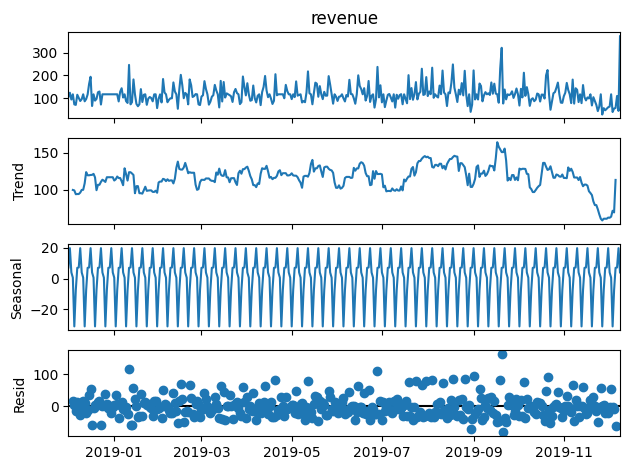

In [102]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decomposition = seasonal_decompose(df_full['revenue'],model='additive')
decomposition.plot();

#### Question 2.2  We will try to use time series model ARIMA for forecasting the future. you need to find the best model with different parameters on ARIMA model. The parameter range for p,d,q are all from [0, 1, 2]. In total, you need to find out the best model with lowest Mean Absolute Error from 27 choices based on the time from ”Jan-01-2019” to ”Nov-01-2019”

In [103]:
# Split the the date from ”Jan-01-2019” to ”Nov-01-2019”
df_date_range=df_full[(df_full['transaction_date'] >= '2019-01-01')&(df_full['transaction_date'] <= '2019-11-01')]

In [104]:
# split the time series to train and test
train=df_date_range[df_date_range.index.month < 8]
test=df_date_range[df_date_range.index.month >= 8]

In [105]:
# Created iteration for p,d and q.
import itertools
p_values = q_values = range(0, 3)
d_values = range(1,2)
pdq = list(itertools.product(p_values, d_values, q_values))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)


In [106]:
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [107]:
from statsmodels.tsa.arima.model import ARIMA
for param in pdq:
    ARIMA_model = ARIMA(train['revenue'].values,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARIMA_AIC = pd.concat([ARIMA_AIC, pd.DataFrame({'param':param , 'AIC': ARIMA_model.aic})], ignore_index=True)

ARIMA(0, 1, 0) - AIC:2254.768669082634
ARIMA(0, 1, 1) - AIC:2117.8977864722738
ARIMA(0, 1, 2) - AIC:2119.887478402092
ARIMA(1, 1, 0) - AIC:2211.1336746839797
ARIMA(1, 1, 1) - AIC:2119.889740378389
ARIMA(1, 1, 2) - AIC:2119.3048043129975
ARIMA(2, 1, 0) - AIC:2185.6169807104325
ARIMA(2, 1, 1) - AIC:2119.489059249714
ARIMA(2, 1, 2) - AIC:2121.258153780208


In [108]:
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def evaluate_arima_model(X, arima_order):
	# prepare training dataset
	train_size = int(len(X) * 0.66)
	train, test = X[0:train_size], X[train_size:]
	history = [x for x in train]
	# make predictions
	predictions = list()
	for t in range(len(test)):
		model = ARIMA(history, order=arima_order)
		model_fit = model.fit()
		yhat = model_fit.forecast()[0]
		predictions.append(yhat)
		history.append(test[t])
	# calculate out of sample error
	mae = mean_absolute_error(test, predictions)
	return mae

In [109]:
def evaluate_models(dataset, p_values, d_values, q_values):
	dataset = dataset.astype('float32')
	best_score, best_cfg = float("inf"), None
	for p in p_values:
		for d in d_values:
			for q in q_values:
				order = (p,d,q)
				try:
					mae = evaluate_arima_model(dataset, order)
					if mae <= best_score:
						best_score, best_cfg = mae, order
					print('ARIMA%s MAE=%.3f' % (order,mae))
				except:
					continue
	print('Best ARIMA%s MAE=%.3f' % (best_cfg, best_score))

In [110]:
# Define parameter ranges for p, d, q
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

# Call the evaluation function on your dataset
evaluate_models(train['revenue'].values, p_values, d_values, q_values)


ARIMA(0, 0, 0) MAE=25.374
ARIMA(0, 0, 1) MAE=25.436
ARIMA(0, 0, 2) MAE=28.237
ARIMA(0, 1, 0) MAE=41.326
ARIMA(0, 1, 1) MAE=25.810
ARIMA(0, 1, 2) MAE=25.732
ARIMA(1, 0, 0) MAE=25.382
ARIMA(1, 0, 1) MAE=27.036
ARIMA(1, 0, 2) MAE=28.515
ARIMA(1, 1, 0) MAE=33.701
ARIMA(1, 1, 1) MAE=25.630
ARIMA(1, 1, 2) MAE=26.157
ARIMA(2, 0, 0) MAE=27.493
ARIMA(2, 0, 1) MAE=28.663
ARIMA(2, 0, 2) MAE=27.670
ARIMA(2, 1, 0) MAE=31.166
ARIMA(2, 1, 1) MAE=27.835
ARIMA(2, 1, 2) MAE=27.339
Best ARIMA(0, 0, 0) MAE=25.374


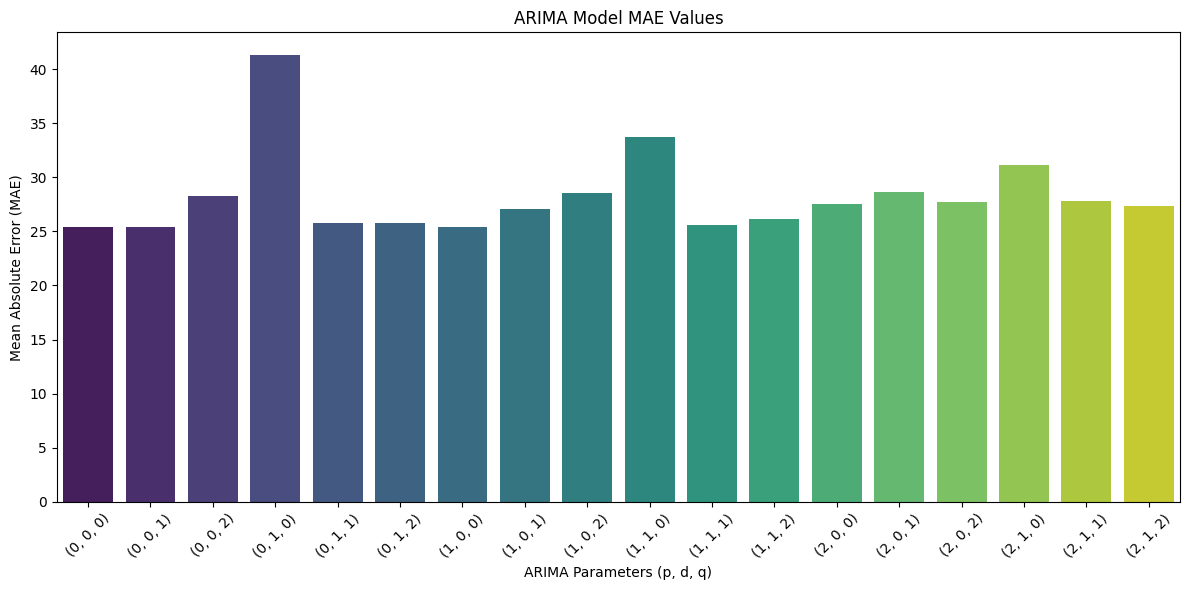

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame from the provided ARIMA results
data = {
    'param': [
        (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 1, 0), (0, 1, 1), (0, 1, 2),
        (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 1, 0), (1, 1, 1), (1, 1, 2),
        (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 1, 0), (2, 1, 1), (2, 1, 2)
    ],
    'MAE': [
        25.374, 25.436, 28.237, 41.326, 25.810, 25.732,
        25.382, 27.036, 28.515, 33.701, 25.630, 26.157,
        27.493, 28.663, 27.670, 31.166, 27.835, 27.339
    ]
}

# Create DataFrame
ARIMA_results = pd.DataFrame(data)

# Convert tuples to strings for plotting
ARIMA_results['param'] = ARIMA_results['param'].astype(str)

# Plotting MAE values for each ARIMA configuration
plt.figure(figsize=(12, 6))
sns.barplot(data=ARIMA_results, x='param', y='MAE', palette='viridis')
plt.title('ARIMA Model MAE Values')
plt.xlabel('ARIMA Parameters (p, d, q)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=45)  # Rotate x labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

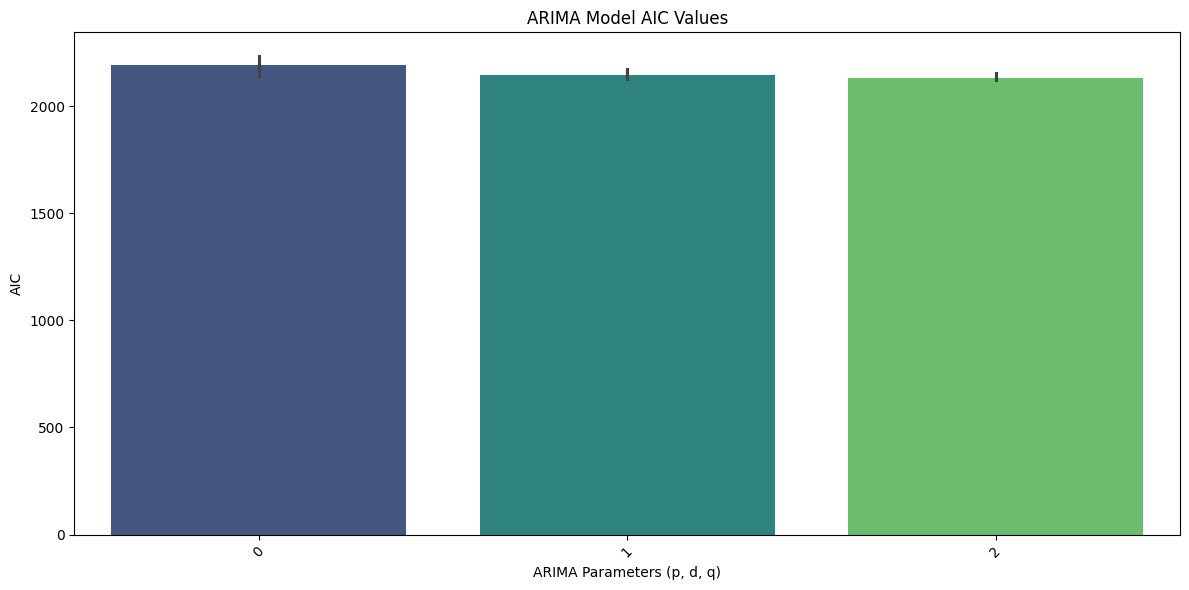

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample DataFrame containing ARIMA parameters and their respective AIC or MAE values
# This should be your ARIMA_AIC DataFrame that contains the results from your ARIMA model evaluation
# For example:
# ARIMA_AIC = pd.DataFrame({'param': [(0,0,0), (0,1,1), (1,1,1)], 'AIC': [165377.7273, 363847.4249, 361994.1287]})

# Ensure you have your ARIMA_AIC DataFrame
# For demonstration, let's create a mock DataFrame (replace this with your actual ARIMA_AIC DataFrame)
# ARIMA_AIC = pd.DataFrame({'param': [(0,0,0), (0,1,1), (1,1,1)], 'AIC': [165377.7273, 361994.1287, 363847.4249]})

# Plotting AIC values for each ARIMA configuration
plt.figure(figsize=(12, 6))
sns.barplot(data=ARIMA_AIC, x='param', y='AIC', palette='viridis')
plt.title('ARIMA Model AIC Values')
plt.xlabel('ARIMA Parameters (p, d, q)')
plt.ylabel('AIC')
plt.xticks(rotation=45)  # Rotate x labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


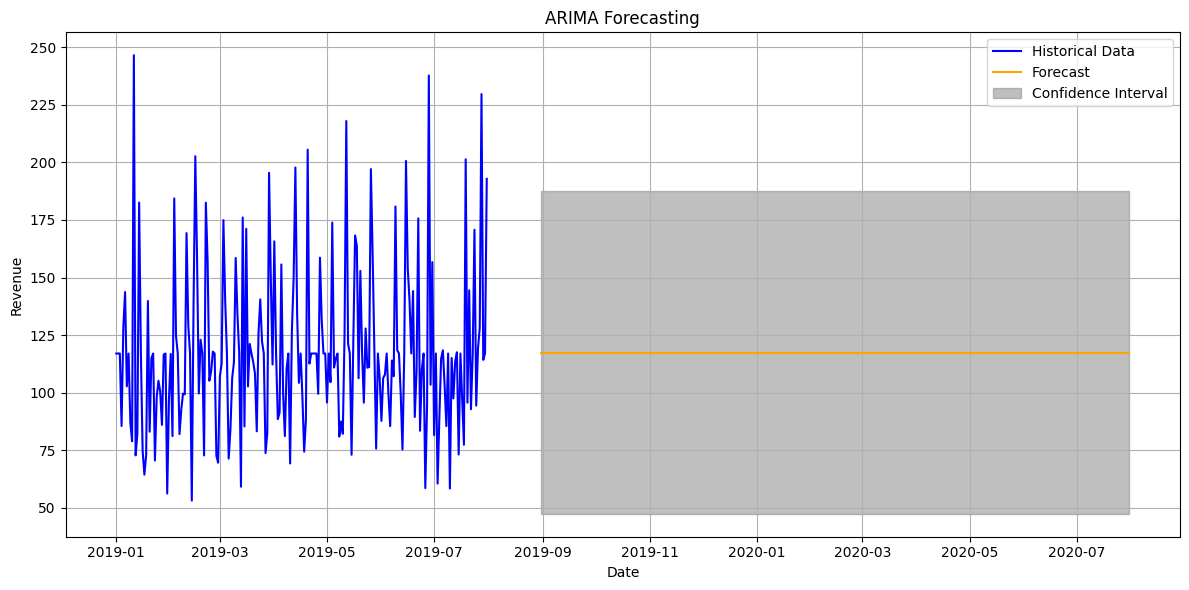

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Fit the best ARIMA model (replace with your actual best order)
best_order = (0, 0, 0)  # Update this with your best ARIMA order
model = ARIMA(train['revenue'].values, order=best_order)
model_fit = model.fit()

# Forecast the next steps (e.g., 12 steps for the next year if monthly data)
forecast_steps = 12
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

# Create a date range for the forecasted values
last_date = train.index[-1]  # Get the last date in the training data
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='M')

# Create a DataFrame for forecasted values
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecast'])
conf_int_df = pd.DataFrame(conf_int, index=forecast_index, columns=['Lower CI', 'Upper CI'])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['revenue'], label='Historical Data', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='orange')
plt.fill_between(conf_int_df.index, conf_int_df['Lower CI'], conf_int_df['Upper CI'], color='gray', alpha=0.5, label='Confidence Interval')
plt.title('ARIMA Forecasting')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### Answer 2.3
### Question 2.3: Deep Learning Time Series Forecasting
#### For this part of the task, we will explore several deep learning models suitable for time series forecasting.
#### Below are the detailed steps for data wrangling and modeling without actual code, along with references to the models used.Data Wrangling Before applying deep learning models to the revenue time series data, the data must be prepared through a series of preprocessing
### steps:
#### Normalization/Scaling: Deep learning models often perform better with normalized data. In this step, we will use MinMaxScaler to scale the revenue data between 0 and 1.
### Steps:
#### Apply MinMaxScaler on the revenue column to normalize the values. Convert the time series data into a supervised learning format using a sliding window approach, where a certain number of previous time steps will be used to predict the next one. Train-Test Split: To evaluate the model's performance, the time series data must be split into training and testing datasets. Typically, the last 20% of the data is used for testing, while the rest is used for training.
#### Modeling Three deep learning models commonly used for time series forecasting are LSTM, GRU, and TCN. Here's how we can apply each of them.
### a) Long Short-Term Memory (LSTM) LSTM is a type of recurrent neural network (RNN) that can capture long-term dependencies in the data. It is particularly useful in time series data forecasting.
### Steps:
#### Define the LSTM model with a stacked architecture. The first LSTM layer will return sequences to feed into the second LSTM layer. Add a Dense layer to output the prediction. Compile the model using Adam as the optimizer and mean squared error (MSE) as the loss function. Train the model on the training data and evaluate it on the test data to check for overfitting or underfitting.
### b) Gated Recurrent Unit (GRU) GRU is another type of recurrent neural network, similar to LSTM but with fewer parameters, making it computationally efficient.
### Steps:
#### Define a GRU model with multiple layers. Compile the model with the same optimizer and loss function as LSTM. Train and validate the model using the split dataset.
### c) Temporal Convolutional Networks (TCN) Temporal Convolutional Networks (TCNs) use convolutional layers rather than recurrent layers to capture temporal dependencies, making them an efficient alternative to RNNs.
### Steps:
#### Build the model using Conv1D layers, which apply convolution over time steps. Stack multiple convolutional layers with different filter sizes to learn patterns across varying time windows. Compile and fit the model on the training data, similar to LSTM and GRU.
#### Model Evaluation After training the models, the next step is to evaluate their performance. We will use Mean Absolute Error (MAE) as the evaluation metric, which calculates the average absolute difference between the predicted and actual values.
### Steps:
#### Use the predict() method to forecast future values from the test data. Compare the predicted values with the actual test data using MAE. Based on the MAE scores, select the best-performing model.
#### References Here are the references for the deep learning models discussed:
#### LSTM: Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. Neural Computation, 9(8), 1735-1780. GRU: Cho, K., et al. (2014). Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation. arXiv preprint. TCN: Bai, S., Kolter, J. Z., & Koltun, V. (2018). An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling. arXiv preprint. Conclusion These are the steps to follow for deep learning-based time series forecasting. Experimenting with different models (LSTM, GRU, TCN) and tuning the hyperparameters is crucial for finding the most accurate prediction model.
### Thank you